# Network Analysis Sandbox
This notebook loads the stock similarity matrix and builds a network using the logic from `main.py`. Use the cells below to explore the graph structure and run custom analysis.

In [1]:
import sys
import os
import networkx as nx
import pandas as pd
from pathlib import Path


def build_network(dist_df):
    print("Building a dense graph from distance matrix...")
    # Create a graph from the distance matrix
    # We use the index/columns as nodes and row values as edge weights
    G = nx.from_pandas_adjacency(dist_df)

    # Remove self-loops (diagonal of the matrix is 0.0 distance)
    G.remove_edges_from(nx.selfloop_edges(G))

    print(
        f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges."
    )
    return G

# Add project root to sys.path to allow importing main.py

sys.path.append(os.path.abspath('.'))

# Configuration
output_dir = Path("output")
print(output_dir)
similarity_file = output_dir / "ticker_similarities.csv"

print(similarity_file)
# Load and process the similarity matrix
if not similarity_file.exists():
    print(f"Error: {similarity_file} not found. Please run data_processor.py first.")
else:
    # Load the similarity matrix
    sim_df = pd.read_csv(similarity_file, index_col=0)

    # Calculate simple cosine distance: d = 1 - s
    cosine_dist = 1.0 - sim_df.values
    dist_df = pd.DataFrame(cosine_dist, index=sim_df.index, columns=sim_df.columns)

    # Build the network using the shared logic
    G = build_network(dist_df)
    print(f"Graph loaded with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

output
output/ticker_similarities.csv
Building a dense graph from distance matrix...
Graph built with 2441 nodes and 2978020 edges.
Graph loaded with 2441 nodes and 2978020 edges.


### Basic Visualization and Top Closest Pairs
Identify the stocks that have the lowest cosine distance (and thus highest similarity).

In [3]:
import pandas as pd

# Use sep='\t' for tabs, or sep='\s+' for one or more spaces
df = pd.read_csv('ticker_metadata/tickers.txt', sep='\t')

# Create a dictionary for easy lookup: {Ticker: Name}
ticker_map = dict(zip(df['ticker'], df['name']))

print(f"Loaded {len(ticker_map)} tickers.")
print(f"Example: AACG -> {ticker_map.get('AACG')}")

Loaded 5637 tickers.
Example: AACG -> ATA Creativity Global American Depositary Shares


In [28]:
import pandas as pd

# Load the SIC codes (assuming tab-separated based on your snippet)
df_sic = pd.read_csv('ticker_metadata/ticker_siccd.txt', sep='\t')

# Create the dictionary: {Ticker: SIC_Code}
# We ensure the SIC code is treated as a string to preserve any leading zeros
sic_map = dict(zip(df_sic['ticker'], df_sic['siccd'].astype(str)))

print(f"Loaded {len(sic_map)} SIC codes.")
print(f"Example: AAL (American Airlines) -> SIC {sic_map.get('AAL')}")

Loaded 5015 SIC codes.
Example: AAL (American Airlines) -> SIC 4512


In [29]:
import networkx as nx

# 1. Add Names
nx.set_node_attributes(new_G, ticker_map, 'name')

# 2. Add SIC Codes
nx.set_node_attributes(new_G, sic_map, 'sic')

# Now you can access data directly from any node:
# print(new_G.nodes['AAL']['name']) -> 'American Airlines Group Inc.'
# print(new_G.nodes['AAL']['sic'])  -> '4512'

In [4]:
# Display Top 10 Closest Ticker Pairs
print("\nTop 10 Closest Ticker Pairs (by Cosine Distance):")
edges = sorted(G.edges(data=True), key=lambda x: x[2].get("weight", 1.0))

count = 0
for u, v, d in edges:
    if count >= 10:
        break
    print(f"{u} <-> {v}: distance = {d['weight']:.4f}")
    count += 1

count = 0
for u, v, d in edges:
    if count >= 10:
        break
    print(f"{u} <-> {v}: distance = {d['weight']:.4f}")
    count += 1



Top 10 Closest Ticker Pairs (by Cosine Distance):
GOOG <-> GOOGL: distance = 0.0001
LILA <-> LILAK: distance = 0.0035
LBRDA <-> LBRDK: distance = 0.0039
CCL <-> CUK: distance = 0.0048
Z <-> ZG: distance = 0.0052
LBTYA <-> LBTYK: distance = 0.0063
FOX <-> FOXA: distance = 0.0075
UA <-> UAA: distance = 0.0099
NWS <-> NWSA: distance = 0.0114
CENT <-> CENTA: distance = 0.0195
GOOG <-> GOOGL: distance = 0.0001
LILA <-> LILAK: distance = 0.0035
LBRDA <-> LBRDK: distance = 0.0039
CCL <-> CUK: distance = 0.0048
Z <-> ZG: distance = 0.0052
LBTYA <-> LBTYK: distance = 0.0063
FOX <-> FOXA: distance = 0.0075
UA <-> UAA: distance = 0.0099
NWS <-> NWSA: distance = 0.0114
CENT <-> CENTA: distance = 0.0195


In [6]:
# Calculate hubs in the Minimum Spanning Tree (MST)
# T is the MST calculated in the previous cell
T = nx.minimum_spanning_tree(G, weight="weight")

# Get degrees for all nodes in the MST
mst_degrees = dict(T.degree())

# Sort nodes by degree in descending order
top_mst_hubs = sorted(mst_degrees.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Hub Nodes in the MST (Highest Degree):")
for node, degree in top_mst_hubs:
    print(f"{node}: degree = {degree}")

# Optional: Highlight these hubs in a printout of their neighbors
print("\nConnections for the top MST hub:")
top_hub = top_mst_hubs[0][0]
neighbors = list(T.neighbors(top_hub))
print(f"{top_hub} is connected to: {', '.join(neighbors)}")


Top 5 Hub Nodes in the MST (Highest Degree):
CSQ: degree = 27
ITT: degree = 25
MCO: degree = 18
HAL: degree = 17
FCF: degree = 15

Connections for the top MST hub:
CSQ is connected to: CHW, TY, CHY, ARES, CZR, MCO, ADSK, CNNE, QTWO, FSV, ALGN, AB, SONO, ATRC, FFIV, STN, ATLC, WING, COST, CALX, FTAI, WMG, FWONK, OSPN, TSLA, ORCL, MFIN


(array([1.532000e+03, 2.097300e+04, 2.496050e+05, 1.063682e+06,
        1.357248e+06, 2.796540e+05, 5.186000e+03, 1.130000e+02,
        1.500000e+01, 1.200000e+01]),
 array([1.37445010e-04, 1.86247813e-01, 3.72358180e-01, 5.58468548e-01,
        7.44578915e-01, 9.30689283e-01, 1.11679965e+00, 1.30291002e+00,
        1.48902039e+00, 1.67513075e+00, 1.86124112e+00]),
 <BarContainer object of 10 artists>)

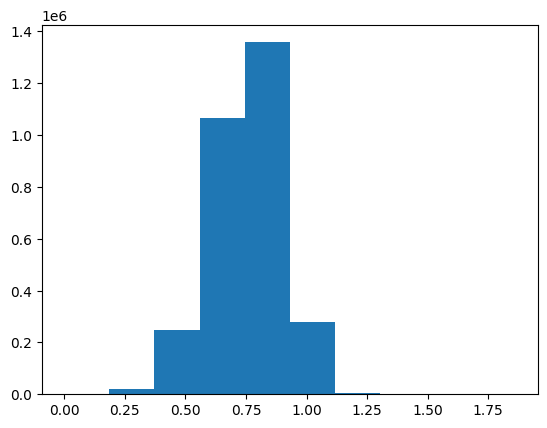

In [7]:
import matplotlib.pyplot as plt

weights = [stock[2]["weight"] for stock in list(G.edges(data=True))]

plt.hist(weights)

#plt.histogram(G.edges(data=True))



0.7537832076619169
9752


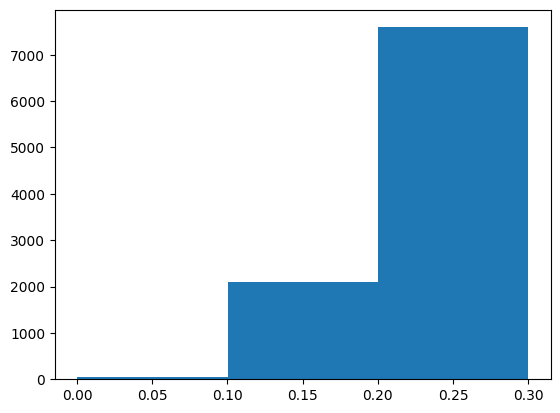

In [8]:
import numpy as np

weights2 = np.array(weights)[np.array(weights) <= 0.3]

bins = np.arange(min(weights2), max(weights2) + 0.1, 0.1)

plt.hist(weights2, bins=bins)
print(np.mean(weights))

max(weights)
print(len(weights2))

In [9]:
import networkx as nx

def threshold_filter(threshold):
    # 1. Create a list of edges that meet your criteria
    # (Weights <= 0.3)
    edges_to_keep = [
        (u, v, d) for u, v, d in G.edges(data=True) 
        if d.get('weight', 1.0) <= threshold
    ]
    
    # 2. Create a new graph from those edges
    # This effectively "filters" the edges in one go
    new_G = nx.Graph()
    new_G.add_nodes_from(G.nodes(data=True)) # Keep node attributes
    new_G.add_edges_from(edges_to_keep)
    
    # 3. Remove isolated nodes (nodes with degree 0)
    isolated_nodes = list(nx.isolates(new_G))
    new_G.remove_nodes_from(isolated_nodes)
    
    print(f"Threshold: {threshold:.1f} | Original nodes: {G.number_of_nodes()} | Filtered nodes: {new_G.number_of_nodes()}")
    print(f"Original edges: {G.number_of_edges()} | Filtered edges: {new_G.number_of_edges()}\n")

    return new_G

for i in range(12):
    threshold_filter(i / 10 + 0.1)

Threshold: 0.1 | Original nodes: 2441 | Filtered nodes: 85
Original edges: 2978020 | Filtered edges: 51

Threshold: 0.2 | Original nodes: 2441 | Filtered nodes: 498
Original edges: 2978020 | Filtered edges: 2153

Threshold: 0.3 | Original nodes: 2441 | Filtered nodes: 945
Original edges: 2978020 | Filtered edges: 9752

Threshold: 0.4 | Original nodes: 2441 | Filtered nodes: 1489
Original edges: 2978020 | Filtered edges: 32773

Threshold: 0.5 | Original nodes: 2441 | Filtered nodes: 1956
Original edges: 2978020 | Filtered edges: 132705

Threshold: 0.6 | Original nodes: 2441 | Filtered nodes: 2302
Original edges: 2978020 | Filtered edges: 423293

Threshold: 0.7 | Original nodes: 2441 | Filtered nodes: 2424
Original edges: 2978020 | Filtered edges: 994266

Threshold: 0.8 | Original nodes: 2441 | Filtered nodes: 2441
Original edges: 2978020 | Filtered edges: 1799729

Threshold: 0.9 | Original nodes: 2441 | Filtered nodes: 2441
Original edges: 2978020 | Filtered edges: 2538311

Threshold: 1

In [10]:
### DEGREE CENTRALITY ###

import networkx as nx

for i in range(12):
    threshold = i / 10 + 0.1

    new_G = threshold_filter(threshold)
    
    
    # 1. Calculate Degree Centrality
    # Note: This is the fraction of nodes it is connected to
    centrality = nx.degree_centrality(new_G)
    hubs = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
    
    # 2. Sort to find the top 5 "Hub" stocks
    top_hubs = hubs[:5]
    
    print("Top Hub Stocks (Normalized Centrality):")
    for ticker, score in top_hubs:
        print(f"{ticker}: {(score * (new_G.number_of_nodes() - 1)):.4f}")
    
    
    scores = [ticker[1] for ticker in hubs]
    print("\n", min(scores), np.percentile(scores, [25, 50, 75]), max(scores), "\n\n")
    

Threshold: 0.1 | Original nodes: 2441 | Filtered nodes: 85
Original edges: 2978020 | Filtered edges: 51

Top Hub Stocks (Normalized Centrality):
DRH: 3.0000
EQR: 3.0000
FITB: 3.0000
KEY: 3.0000
RLJ: 3.0000

 0.011904761904761904 [0.01190476 0.01190476 0.01190476] 0.03571428571428571 


Threshold: 0.2 | Original nodes: 2441 | Filtered nodes: 498
Original edges: 2978020 | Filtered edges: 2153

Top Hub Stocks (Normalized Centrality):
CATY: 79.0000
FCF: 76.0000
ABCB: 74.0000
FRME: 71.0000
HOPE: 70.0000

 0.002012072434607646 [0.00201207 0.00402414 0.01609658] 0.15895372233400404 


Threshold: 0.3 | Original nodes: 2441 | Filtered nodes: 945
Original edges: 2978020 | Filtered edges: 9752

Top Hub Stocks (Normalized Centrality):
CATY: 139.0000
HWC: 136.0000
ABCB: 135.0000
FCF: 135.0000
ASB: 134.0000

 0.001059322033898305 [0.00211864 0.00529661 0.01694915] 0.1472457627118644 


Threshold: 0.4 | Original nodes: 2441 | Filtered nodes: 1489
Original edges: 2978020 | Filtered edges: 32773

Top H

In [11]:
import networkx as nx
import community.community_louvain as community_louvain

# Assuming G is your NetworkX graph with similarity weights
# Louvain prefers higher weights for stronger connections
partition_louvain = community_louvain.best_partition(G, weight='weight')

# Count how many clusters were found
clusters_found = len(set(partition_louvain.values()))
print(f"Louvain found {clusters_found} clusters.")

ModuleNotFoundError: No module named 'community'

In [31]:
import networkx as nx
import numpy as np
from sklearn.cluster import SpectralClustering

new_G = threshold_filter(0.3)

# 1. Convert your NetworkX graph to a weighted adjacency matrix
# This creates a 2500x2500 matrix
adj_matrix = nx.to_numpy_array(new_G, weight='weight')

# 2. Define the Spectral Clustering model
# 'affinity=precomputed' tells it we are passing a similarity matrix, not raw data
sc = SpectralClustering(
    n_clusters=15,           # You must specify the number of clusters
    affinity='precomputed', 
    assign_labels='discretize', 
    random_state=3
)

# 3. Fit the model
# Returns an array of cluster labels corresponding to the matrix rows
cluster_labels = sc.fit_predict(adj_matrix)

# 4. Map back to your Tickers
# nx.nodes(new_G) gives the order of tickers used in the matrix
nodes = list(new_G.nodes())
spectral_partition = {nodes[i]: cluster_labels[i] for i in range(len(nodes))}

print(f"Assigned {len(nodes)} stocks to {10} clusters.")

Threshold: 0.3 | Original nodes: 2441 | Filtered nodes: 945
Original edges: 2978020 | Filtered edges: 9752



/Users/tomseifert/opt/anaconda3/envs/networks_w26/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Assigned 945 stocks to 10 clusters.


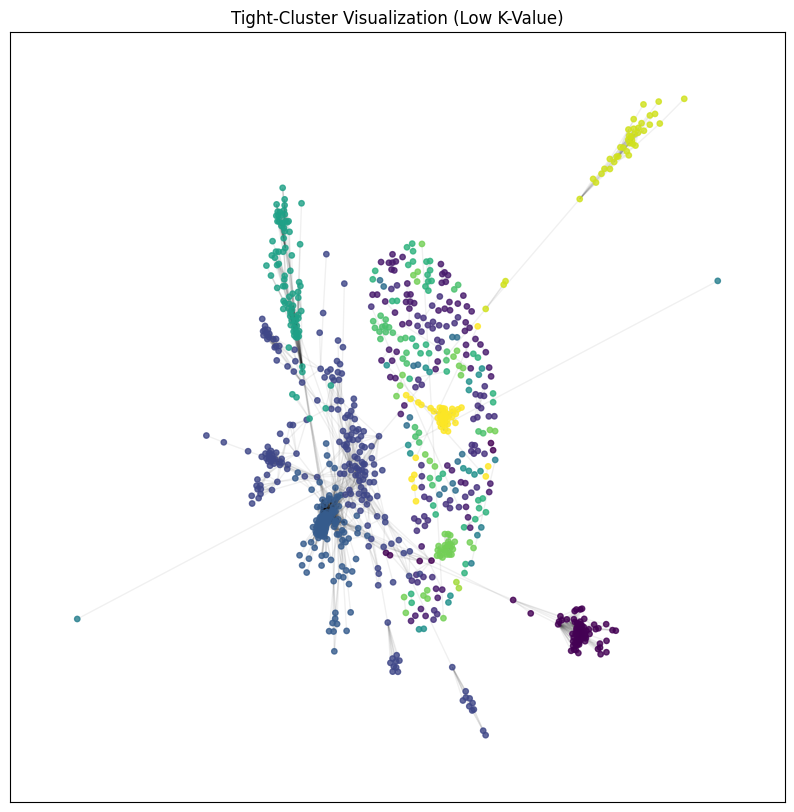

In [32]:
import matplotlib.pyplot as plt
import networkx as nx

# k: Optimal distance between nodes (default is 1/sqrt(n))
# Increase iterations to allow clusters to compress more
pos = nx.spring_layout(new_G, k=0.05, iterations=300, weight='weight', seed=33)

plt.figure(figsize=(10, 10))

# Draw nodes colored by your spectral clusters
colors = [spectral_partition[node] for node in new_G.nodes()]
nx.draw_networkx_nodes(new_G, pos, node_size=15, node_color=colors, cmap='viridis', alpha=0.8)

# Draw edges with very low alpha so they don't clutter the "clumps"
nx.draw_networkx_edges(new_G, pos, alpha=0.06)

plt.title("Tight-Cluster Visualization (Low K-Value)")
plt.show()

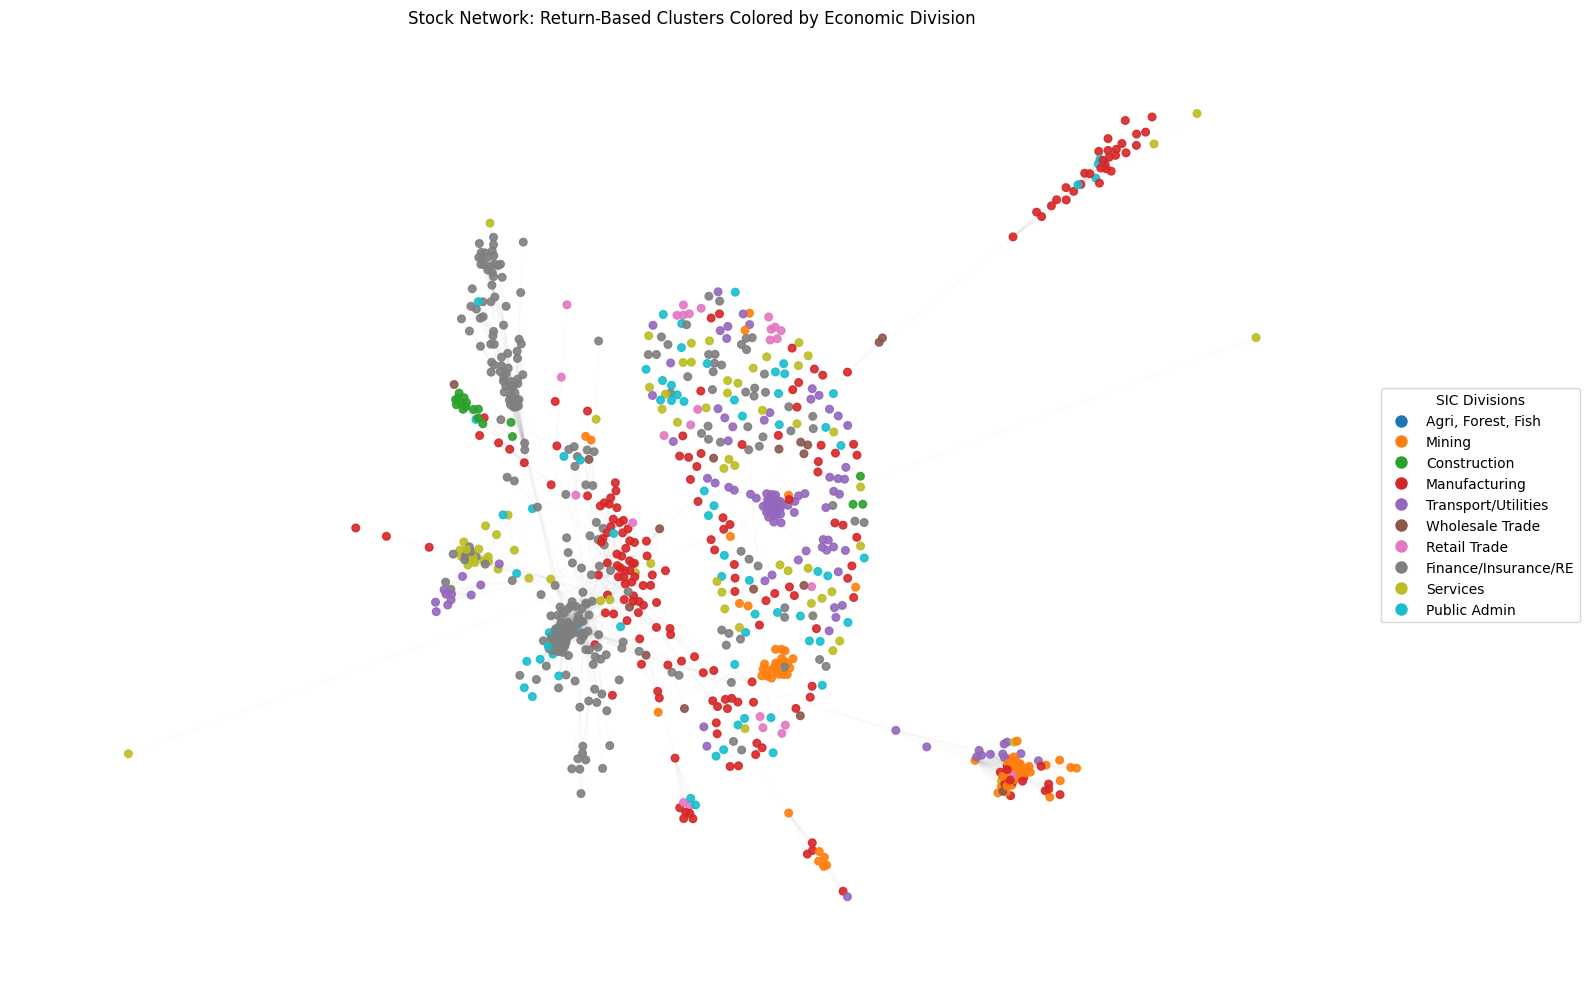

In [44]:
def get_division(sic_str):
    try:
        major = int(sic_str[:2])
    except ValueError:
        return "Unknown"
    
    if 1 <= major <= 9: return "Agri, Forest, Fish"
    if 10 <= major <= 14: return "Mining"
    if 15 <= major <= 17: return "Construction"
    if 20 <= major <= 39: return "Manufacturing"
    if 40 <= major <= 49: return "Transport/Utilities"
    if 50 <= major <= 51: return "Wholesale Trade"
    if 52 <= major <= 59: return "Retail Trade"
    if 60 <= major <= 67: return "Finance/Insurance/RE"
    if 70 <= major <= 89: return "Services"
    if 90 <= major <= 99: return "Public Admin"
    return "Unknown"

# 3. APPLY ATTRIBUTES TO GRAPH
for node in new_G.nodes():
    raw_sic = sic_map.get(node, "0000")
    division = get_division(raw_sic)
    new_G.nodes[node]['division'] = division

# 4. COLOR PREPARATION
# Define a stable color palette for the divisions
divisions_list = [
    "Agri, Forest, Fish", "Mining", "Construction", "Manufacturing", 
    "Transport/Utilities", "Wholesale Trade", "Retail Trade", 
    "Finance/Insurance/RE", "Services", "Public Admin", "Unknown"
]
cmap = plt.get_cmap('tab10', len(divisions_list))
div_to_color = {div: cmap(i) for i, div in enumerate(divisions_list)}

node_colors = [div_to_color[new_G.nodes[n]['division']] for n in new_G.nodes()]

# 5. VISUALIZATION
plt.figure(figsize=(16, 10))

# Reuse your optimized layout parameters
pos = nx.spring_layout(new_G, k=0.05, iterations=300, weight='weight', seed=33)

# Draw graph components
nx.draw_networkx_edges(new_G, pos, alpha=0.03, edge_color='gray')
nx.draw_networkx_nodes(new_G, pos, node_size=30, node_color=node_colors, alpha=0.9)

# 6. CREATE THE DIVISION KEY
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=div,
           markerfacecolor=color, markersize=10)
    for div, color in div_to_color.items() if div != "Unknown"
]

plt.legend(handles=legend_elements, title="SIC Divisions", 
           loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

plt.title("Stock Network: Return-Based Clusters Colored by Economic Division")
plt.axis('off')
plt.tight_layout()
plt.show()